In [1]:
# Path to user functions
import sys
sys.path.append("../Src/")
# display Python Version
from platform import python_version
# import libraries
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from haversine import haversine, haversine_vector, Unit 
import time
from datetime import datetime
# user functions
import utilities as u
import statistical_testing as st
import plot_function as pf

# Initialize variables
RANDOM_STATE = 1776

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Polars Version: " + pl.__version__)
print("Python Version: " + python_version())

Numpy Version: 2.3.3
Pandas Version: 2.3.3
Seaborn Version: 0.13.2
Matplotlib Version: 3.10.7
Polars Version: 1.34.0
Python Version: 3.13.5


### Load the dataset & Combine the train and test datasets

In [2]:
# using Pandas to load csv file
%timeit df = pd.read_csv("../Data/fraudTrain.csv")

2.08 s ± 20.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [3]:
# using Polars to load csv file
%timeit df_pl = pl.read_csv("../Data/fraudTrain.csv")

51.5 ms ± 111 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [4]:
# Load the CSV files
print("Loading fraudTrain.csv...")
start = time.perf_counter()
df = pd.read_csv("../Data/fraudTrain.csv")
end = time.perf_counter()
print(f"Training data shape: {df.shape}")
print(f"\nTime taken to load fraudTrain.csv: {end - start:.4f} seconds")

Loading fraudTrain.csv...
Training data shape: (1296675, 23)

Time taken to load fraudTrain.csv: 2.1372 seconds


In [5]:
# use Polars to load csv file
start = time.perf_counter()
print("Loading fraudTrain.csv...")
df_pl = pl.read_csv("../Data/fraudTrain.csv")
end = time.perf_counter()
print(f"Training data shape (Polars): {df_pl.shape}")
print(f"\nTime taken to load fraudTrain.csv: {end - start:.4f} seconds")

Loading fraudTrain.csv...
Training data shape (Polars): (1296675, 23)

Time taken to load fraudTrain.csv: 0.0501 seconds


In [6]:
%timeit df.head()

4.19 μs ± 17.2 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [7]:
%timeit df_pl.head()

1.56 μs ± 3.36 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [8]:
pd.set_option('display.max_rows', None)
# Check for NaNs Pandas
%timeit df.isnull().sum()

223 ms ± 1.01 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [9]:
pl.Config.set_tbl_rows(-1)
# Check for NaNs using Polars
%timeit df_pl.null_count().transpose(column_names=True, include_header=True)

35.2 μs ± 238 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [10]:
# Check Data Types
%timeit df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [11]:
%timeit df_pl.schema

5.64 μs ± 12.3 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [12]:
%%timeit
print(f"Number of rows: {df_pl.height:,}")
print(f"Estimated memory size (GB): {df_pl.estimated_size(unit="gb"):,.4f}")

Number of rows: 1,296,675
Estimated memory size (GB): 0.3006
Number of rows: 1,296,675
Estimated memory size (GB): 0.3006
Number of rows: 1,296,675
Estimated memory size (GB): 0.3006
Number of rows: 1,296,675
Estimated memory size (GB): 0.3006
Number of rows: 1,296,675
Estimated memory size (GB): 0.3006
Number of rows: 1,296,675
Estimated memory size (GB): 0.3006
Number of rows: 1,296,675
Estimated memory size (GB): 0.3006
Number of rows: 1,296,675
Estimated memory size (GB): 0.3006
Number of rows: 1,296,675
Estimated memory size (GB): 0.3006
Number of rows: 1,296,675
Estimated memory size (GB): 0.3006
Number of rows: 1,296,675
Estimated memory size (GB): 0.3006
Number of rows: 1,296,675
Estimated memory size (GB): 0.3006
Number of rows: 1,296,675
Estimated memory size (GB): 0.3006
Number of rows: 1,296,675
Estimated memory size (GB): 0.3006
Number of rows: 1,296,675
Estimated memory size (GB): 0.3006
Number of rows: 1,296,675
Estimated memory size (GB): 0.3006
Number of rows: 1,296,67

In [13]:
%%timeit
df.is_fraud.value_counts()

2.69 ms ± 24.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [14]:
print(df.is_fraud.value_counts(normalize=True))

is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64


In [15]:
print(df_pl['is_fraud'].value_counts())

shape: (2, 2)
┌──────────┬─────────┐
│ is_fraud ┆ count   │
│ ---      ┆ ---     │
│ i64      ┆ u32     │
╞══════════╪═════════╡
│ 0        ┆ 1289169 │
│ 1        ┆ 7506    │
└──────────┴─────────┘


In [16]:
print(df_pl['is_fraud'].value_counts(normalize=True, sort=True))

shape: (2, 2)
┌──────────┬────────────┐
│ is_fraud ┆ proportion │
│ ---      ┆ ---        │
│ i64      ┆ f64        │
╞══════════╪════════════╡
│ 0        ┆ 0.994211   │
│ 1        ┆ 0.005789   │
└──────────┴────────────┘


### Observations :
- From above we can observe that there is 23 features and 1,289,169 total rows
- 0: 1,289,169 & 1: 7,506
- This is highly imbalanced class data

### Data Wrangling

In [17]:
start = time.perf_counter()
# Convert trans_date_trans_time to datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
# Convert dob to datetime
df['dob'] = pd.to_datetime(df['dob'])

# remove 'fraud_' prefix from the 'merchant' column
df['merchant'] = df['merchant'].str.replace('^fraud_', '', regex=True)

end = time.perf_counter()
print(f"\nTime taken to change data types and clean columns: {end - start:.4f} seconds\n")
# display
print(df[["trans_date_trans_time","dob"]].head())


Time taken to change data types and clean columns: 0.4991 seconds

  trans_date_trans_time        dob
0   2019-01-01 00:00:18 1988-03-09
1   2019-01-01 00:00:44 1978-06-21
2   2019-01-01 00:00:51 1962-01-19
3   2019-01-01 00:01:16 1967-01-12
4   2019-01-01 00:03:06 1986-03-28


In [18]:

start = time.perf_counter()
# Convert trans_date_trans_time to datetime & dob to datetime
df_pl = df_pl.with_columns([
    pl.col("trans_date_trans_time").str.to_datetime().alias("trans_date_trans_time"),
    pl.col("dob").str.to_date().alias("dob")
])
df_pl = df_pl.with_columns(
    pl.col("merchant").str.replace(r"^fraud_", "").alias("merchant")
)

end = time.perf_counter()
print(f"\nTime taken to change data types and clean columns: {end - start:.4f} seconds\n")

# display
print(df_pl[["trans_date_trans_time","dob"]].head())


Time taken to change data types and clean columns: 0.1941 seconds

shape: (5, 2)
┌───────────────────────┬────────────┐
│ trans_date_trans_time ┆ dob        │
│ ---                   ┆ ---        │
│ datetime[μs]          ┆ date       │
╞═══════════════════════╪════════════╡
│ 2019-01-01 00:00:18   ┆ 1988-03-09 │
│ 2019-01-01 00:00:44   ┆ 1978-06-21 │
│ 2019-01-01 00:00:51   ┆ 1962-01-19 │
│ 2019-01-01 00:01:16   ┆ 1967-01-12 │
│ 2019-01-01 00:03:06   ┆ 1986-03-28 │
└───────────────────────┴────────────┘


## Feature Engineering

In [19]:
# Current date
today = datetime.now().date()

start = time.perf_counter()

# determine month, day of the week
df['trans_qtr'] = df['trans_date_trans_time'].dt.quarter
df['trans_month'] = df['trans_date_trans_time'].dt.month
df['trans_day'] = df['trans_date_trans_time'].dt.day
df['trans_day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['trans_hour'] = df['trans_date_trans_time'].dt.hour
df['trans_week_of_year'] = df['trans_date_trans_time'].dt.isocalendar().week
df['is_weekend'] = df['trans_day_of_week'].isin([5, 6]).astype(int)

# For cyclical features like month, day_of_week, hour_of_day, consider sine and cosine transformations to preserve their cyclical nature 
# (e.g., 23:00 is closer to 00:00 than to 12:00).
# For example, you can create sine and cosine transformations for the hour of the day:
df['trans_hour_sin'] = np.sin(2 * np.pi * df['trans_hour'].astype(int) / 24)
df['trans_hour_cos'] = np.cos(2 * np.pi * df['trans_hour'].astype(int) / 24)

df['trans_month_sin'] = np.sin(2 * np.pi * df['trans_month'].astype(int) / 12)
df['trans_month_cos'] = np.cos(2 * np.pi * df['trans_month'].astype(int) / 12)
df['trans_day_of_week_sin'] = np.sin(2 * np.pi * df['trans_day_of_week'].astype(int) / 7)
df['trans_day_of_week_cos'] = np.cos(2 * np.pi * df['trans_day_of_week'].astype(int) / 7)

# Calculate age
df['age'] = df['dob'].apply(lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day)))

end = time.perf_counter()
print(f"\nTime taken to change data types and clean columns: {end - start:.4f} seconds\n")
# display
df.head()


Time taken to change data types and clean columns: 0.7610 seconds



,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,trans_hour,trans_week_of_year,is_weekend,trans_hour_sin,trans_hour_cos,trans_month_sin,trans_month_cos,trans_day_of_week_sin,trans_day_of_week_cos,age
0,0,2019-01-01 00:00:18,2703186189652095,"Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,0,1,0,0.0,1.0,0.5,0.866025,0.781831,0.62349,37
1,1,2019-01-01 00:00:44,630423337322,"Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,0,1,0,0.0,1.0,0.5,0.866025,0.781831,0.62349,47
2,2,2019-01-01 00:00:51,38859492057661,Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,0,1,0,0.0,1.0,0.5,0.866025,0.781831,0.62349,63
3,3,2019-01-01 00:01:16,3534093764340240,"Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,0,1,0,0.0,1.0,0.5,0.866025,0.781831,0.62349,58
4,4,2019-01-01 00:03:06,375534208663984,Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,0,1,0,0.0,1.0,0.5,0.866025,0.781831,0.62349,39


In [20]:
start = time.perf_counter()
# determine quarter, month, day of the week, and hour using Polars
df_pl = df_pl.with_columns([
    pl.col("trans_date_trans_time").dt.quarter().alias("trans_qtr"),
    pl.col("trans_date_trans_time").dt.month().alias("trans_month"),
    pl.col("trans_date_trans_time").dt.day().alias("trans_day"),
    # Adjusting day_of_week to have Monday=0, Sunday=6 (as in Pandas)
    (pl.col("trans_date_trans_time").dt.weekday() - 1).alias("trans_day_of_week"),
    pl.col("trans_date_trans_time").dt.hour().alias("trans_hour"),
    # Polars does not currently support isocalendar().week directly; if needed, use apply (less performant) or preprocess externally
    # pl.col("trans_date_trans_time").dt.isocalendar().week().alias("trans_week_of_year"),
    (pl.col("trans_date_trans_time").dt.weekday().is_in([5,6])).cast(pl.Int8).alias("is_weekend"),
])

# Add cyclical sine and cosine transformations as new columns
df_pl = df_pl.with_columns([
    (pl.col("trans_hour").cast(pl.Float64) * 2 * np.pi / 24).sin().alias("trans_hour_sin"),
    (pl.col("trans_hour").cast(pl.Float64) * 2 * np.pi / 24).cos().alias("trans_hour_cos"),
    (pl.col("trans_month").cast(pl.Float64) * 2 * np.pi / 12).sin().alias("trans_month_sin"),
    (pl.col("trans_month").cast(pl.Float64) * 2 * np.pi / 12).cos().alias("trans_month_cos"),
    (pl.col("trans_day_of_week").cast(pl.Float64) * 2 * np.pi / 7).sin().alias("trans_day_of_week_sin"),
    (pl.col("trans_day_of_week").cast(pl.Float64) * 2 * np.pi / 7).cos().alias("trans_day_of_week_cos"),
])

# Calculate age: difference of years minus 1 if birthday hasn't occurred this year yet
df_pl = df_pl.with_columns(
    (
        (pl.lit(today.year) - pl.col("dob").dt.year())
        - (
            (pl.lit(today.month) < pl.col("dob").dt.month())
            | (
                (pl.lit(today.month) == pl.col("dob").dt.month())
                & (pl.lit(today.day) < pl.col("dob").dt.day())
            )
        ).cast(pl.Int8)
    ).alias("age")
)

end = time.perf_counter()
print(f"\nTime taken to change data types and clean columns: {end - start:.4f} seconds\n")
# display
df_pl.head()


Time taken to change data types and clean columns: 0.0208 seconds



,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_qtr,trans_month,trans_day,trans_day_of_week,trans_hour,is_weekend,trans_hour_sin,trans_hour_cos,trans_month_sin,trans_month_cos,trans_day_of_week_sin,trans_day_of_week_cos,age
i64,datetime[μs],i64,str,str,f64,str,str,str,str,str,str,i64,f64,f64,i64,str,date,str,i64,f64,f64,i64,i8,i8,i8,i8,i8,i8,f64,f64,f64,f64,f64,f64,i32
0,2019-01-01 00:00:18,2703186189652095,"""Rippin, Kub and Mann""","""misc_net""",4.97,"""Jennifer""","""Banks""","""F""","""561 Perry Cove""","""Moravian Falls""","""NC""",28654,36.0788,-81.1781,3495,"""Psychologist, counselling""",1988-03-09,"""0b242abb623afc578575680df30655…",1325376018,36.011293,-82.048315,0,1,1,1,1,0,0,0.0,1.0,0.5,0.866025,0.781831,0.62349,37
1,2019-01-01 00:00:44,630423337322,"""Heller, Gutmann and Zieme""","""grocery_pos""",107.23,"""Stephanie""","""Gill""","""F""","""43039 Riley Greens Suite 393""","""Orient""","""WA""",99160,48.8878,-118.2105,149,"""Special educational needs teac…",1978-06-21,"""1f76529f8574734946361c461b024d…",1325376044,49.159047,-118.186462,0,1,1,1,1,0,0,0.0,1.0,0.5,0.866025,0.781831,0.62349,47
2,2019-01-01 00:00:51,38859492057661,"""Lind-Buckridge""","""entertainment""",220.11,"""Edward""","""Sanchez""","""M""","""594 White Dale Suite 530""","""Malad City""","""ID""",83252,42.1808,-112.262,4154,"""Nature conservation officer""",1962-01-19,"""a1a22d70485983eac12b5b88dad1cf…",1325376051,43.150704,-112.154481,0,1,1,1,1,0,0,0.0,1.0,0.5,0.866025,0.781831,0.62349,63
3,2019-01-01 00:01:16,3534093764340240,"""Kutch, Hermiston and Farrell""","""gas_transport""",45.0,"""Jeremy""","""White""","""M""","""9443 Cynthia Court Apt. 038""","""Boulder""","""MT""",59632,46.2306,-112.1138,1939,"""Patent attorney""",1967-01-12,"""6b849c168bdad6f867558c3793159a…",1325376076,47.034331,-112.561071,0,1,1,1,1,0,0,0.0,1.0,0.5,0.866025,0.781831,0.62349,58
4,2019-01-01 00:03:06,375534208663984,"""Keeling-Crist""","""misc_pos""",41.96,"""Tyler""","""Garcia""","""M""","""408 Bradley Rest""","""Doe Hill""","""VA""",24433,38.4207,-79.4629,99,"""Dance movement psychotherapist""",1986-03-28,"""a41d7549acf90789359a9aa5346dcb…",1325376186,38.674999,-78.632459,0,1,1,1,1,0,0,0.0,1.0,0.5,0.866025,0.781831,0.62349,39


### New Features

In [21]:
%%timeit
# determine store distance
df['store_distance_haversine_km'] = df.apply(lambda row: haversine(
    (row['lat'], row['long']), (row['merch_lat'], row['merch_long']), Unit.KILOMETERS
), axis=1)

6.1 s ± 30.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [22]:
%%timeit
# Convert to tuples of (lat, lon)
home_coords = list(zip(df['lat'], df['long']))
store_coords = list(zip(df['merch_lat'], df['merch_long']))
# Compute vectorized distances (in kilometers)
df['store_distance_haversine_km'] = haversine_vector(home_coords, store_coords, Unit.KILOMETERS)

536 ms ± 8.27 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [23]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,trans_week_of_year,is_weekend,trans_hour_sin,trans_hour_cos,trans_month_sin,trans_month_cos,trans_day_of_week_sin,trans_day_of_week_cos,age,store_distance_haversine_km
0,0,2019-01-01 00:00:18,2703186189652095,"Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,1,0,0.0,1.0,0.5,0.866025,0.781831,0.62349,37,78.597677
1,1,2019-01-01 00:00:44,630423337322,"Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,1,0,0.0,1.0,0.5,0.866025,0.781831,0.62349,47,30.212217
2,2,2019-01-01 00:00:51,38859492057661,Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,1,0,0.0,1.0,0.5,0.866025,0.781831,0.62349,63,108.206232
3,3,2019-01-01 00:01:16,3534093764340240,"Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,1,0,0.0,1.0,0.5,0.866025,0.781831,0.62349,58,95.673363
4,4,2019-01-01 00:03:06,375534208663984,Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,1,0,0.0,1.0,0.5,0.866025,0.781831,0.62349,39,77.556851


In [24]:
%%timeit
# Create a mapping for industry identifier
mii_to_industry = {
    '1': 'Airlines',
    '2': 'Airlines & Financial',
    '3': 'Travel & Entertainment (e.g., American Express, Diners Club)',
    '4': 'Banking & Financial (e.g., Visa)',
    '5': 'Banking & Financial (e.g., Mastercard)',
    '6': 'Merchandising & Banking (e.g., Discover)',
    '7': 'Petroleum',
    '8': 'Healthcare & Telecommunications',
    '9': 'National Assignment / Other'
}

# Extract first digit of cc_num as string and map directly
df['industry'] = df['cc_num'].astype(str).str[0].map(mii_to_industry)

# Determine credit card network
df['cc_network'] = df['cc_num'].astype(str).apply(u.get_credit_card_network)

# Log transformation
df['amt_log'] = np.log1p(df['amt'])  # Using log1p
df['city_pop_log'] = np.log1p(df['city_pop'])  # Using log1p

# Convert 'is_fraud' to a numeric type (int or float)
df['is_fraud'] = df['is_fraud'].astype(int)  # or float, depending on your data

# Define categorical columns
cat_cols = ['merchant', 'category', 'gender', 'city', 'state', 'zip', 'job', 'trans_qtr', 'trans_month', 'trans_day',  
            'trans_day_of_week', 'trans_hour', 'trans_week_of_year', 'industry', 'cc_network']
df[cat_cols] = df[cat_cols].astype('category')

2.34 s ± 24.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [25]:
# Display
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,trans_month_sin,trans_month_cos,trans_day_of_week_sin,trans_day_of_week_cos,age,store_distance_haversine_km,industry,cc_network,amt_log,city_pop_log
0,0,2019-01-01 00:00:18,2703186189652095,"Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,0.5,0.866025,0.781831,0.62349,37,78.597677,Airlines & Financial,Mastercard,1.786747,8.159375
1,1,2019-01-01 00:00:44,630423337322,"Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,0.5,0.866025,0.781831,0.62349,47,30.212217,"Merchandising & Banking (e.g., Discover)",Maestro,4.684259,5.010635
2,2,2019-01-01 00:00:51,38859492057661,Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,0.5,0.866025,0.781831,0.62349,63,108.206232,"Travel & Entertainment (e.g., American Express...",Diners Club,5.398660,8.332068
3,3,2019-01-01 00:01:16,3534093764340240,"Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,0.5,0.866025,0.781831,0.62349,58,95.673363,"Travel & Entertainment (e.g., American Express...",JCB,3.828641,7.570443
4,4,2019-01-01 00:03:06,375534208663984,Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,0.5,0.866025,0.781831,0.62349,39,77.556851,"Travel & Entertainment (e.g., American Express...",American Express,3.760269,4.605170


## Visualization

--- Chi-Square Test between 'trans_hour' and 'is_fraud' ---
Contingency Table (Observed):
is_fraud    0 (count)  1 (count)  0 (%)  1 (%)
trans_hour                                    
0               41867        635   3.25   8.46
1               42211        658   3.27   8.77
2               42031        625   3.26   8.33
3               42160        609   3.27   8.11
4               41817         46   3.24   0.61
5               42111         60   3.27   0.80
6               42260         40   3.28   0.53
7               42147         56   3.27   0.75
8               42456         49   3.29   0.65
9               42138         47   3.27   0.63
10              42231         40   3.28   0.53
11              42040         42   3.26   0.56
12              65190         67   5.06   0.89
13              65234         80   5.06   1.07
14              64799         86   5.03   1.15
15              65312         79   5.07   1.05
16              65650         76   5.09   1.01
17              6

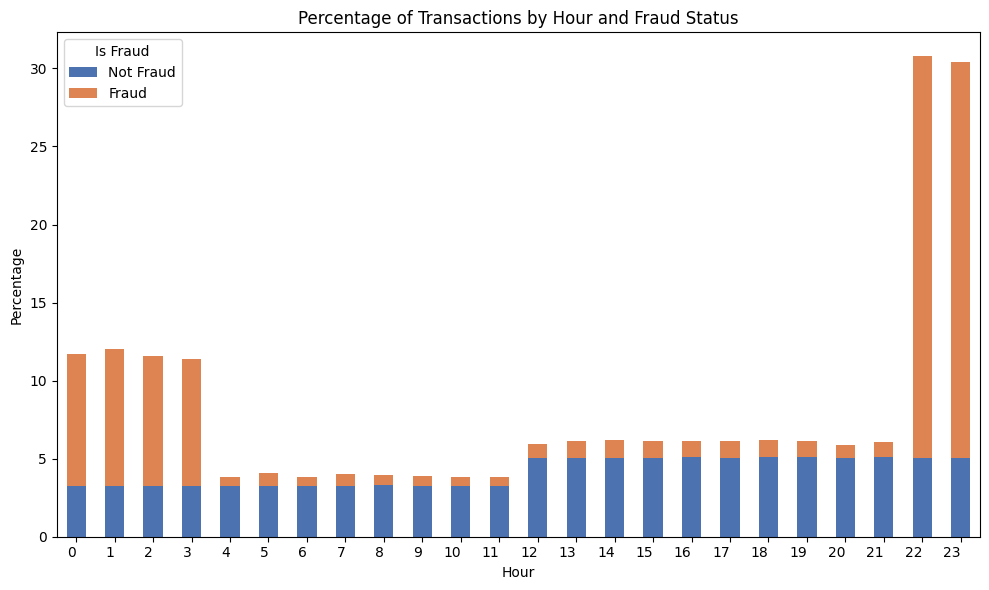

In [26]:
# Perform Chi-Square Test
contingency_table_percent = st.chi_square_test(df, 'trans_hour', 'is_fraud')
contingency_table_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#4c72b0', '#dd8452']  # Optional: custom colors for clarity
)

plt.ylabel('Percentage')
plt.xlabel('Hour')
plt.title('Percentage of Transactions by Hour and Fraud Status')
plt.legend(['Not Fraud', 'Fraud'], title='Is Fraud')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()


#### Summary
- The Chi-Square test provides strong statistical evidence to conclude that there is a significant association between the hour of a transaction and whether or not it is fraudulent.
- Fraudulent transactions are disproportionately higher during late-night and early-morning hours (00-03 and especially 22-23). For instance, 25.71% of all fraudulent transactions occur at 22:00, and 25.30% at 23:00, even though these hours account for only about 5% of non-fraudulent transactions.
- Conversely, daytime hours (roughly 04:00 to 21:00) generally see a lower percentage of fraudulent transactions relative to non-fraudulent ones.

--- Chi-Square Test between 'trans_day_of_week' and 'is_fraud' ---
Contingency Table (Observed):
is_fraud           0 (count)  1 (count)  0 (%)  1 (%)
trans_day_of_week                                    
0                     253100       1182  19.63  15.75
1                     159292        935  12.36  12.46
2                     130214        859  10.10  11.44
3                     146277       1008  11.35  13.43
4                     151193       1079  11.73  14.38
5                     199730       1227  15.49  16.35
6                     249363       1216  19.34  16.20

Expected Frequencies:
is_fraud                       0            1
trans_day_of_week                            
0                  252810.050057  1471.949943
1                  159299.501697   927.498303
2                  130314.264050   758.735950
3                  146432.418428   852.581572
4                  151390.550422   881.449578
5                  199793.729912  1163.270088
6                  249128.

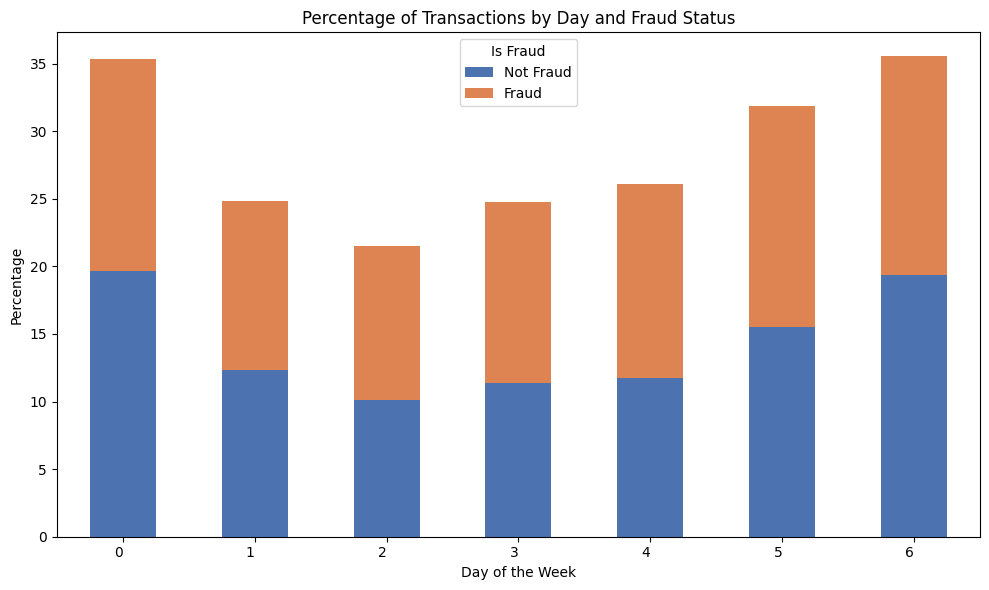

In [27]:
# Perform Chi-Square Test
contingency_table_percent = st.chi_square_test(df, 'trans_day_of_week', 'is_fraud')
contingency_table_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#4c72b0', '#dd8452']  # Optional: custom colors for clarity
)

plt.ylabel('Percentage')
plt.xlabel('Day of the Week')
plt.title('Percentage of Transactions by Day and Fraud Status')
plt.legend(['Not Fraud', 'Fraud'], title='Is Fraud')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

#### Summary

- There is a statistically significant relationship between the day of the week and whether a transaction is fraudulent.
- This statistical significance supports the observation that fraudulent activity tends to be more concentrated toward the end of the week.
    - Thursday and Friday have a higher share of fraudulent transactions (13.65% and 14.26% respectively) compared to their share of non-fraudulent transactions (11.15% and 11.60%). This suggests an elevated risk on these days.
    - Monday and Sunday show a lower share of fraudulent transactions (15.38% and 16.47%) relative to their non-fraudulent volume (19.97% and 18.56%), indicating a comparatively lower risk.
    - Saturday fraud is roughly proportionate to its transaction volume, with its share of fraudulent transactions (15.47%) being very close to its share of non-fraudulent transactions (14.20%).
- Fraudulent activity tends to be more concentrated toward the end of the week, particularly on Thursday and Friday. This could reflect the behavioral patterns of fraudsters, who may exploit the end-of-week rush or reduced oversight. 

--- Chi-Square Test between 'trans_month' and 'is_fraud' ---
Contingency Table (Observed):
is_fraud     0 (count)  1 (count)  0 (%)  1 (%)
trans_month                                    
1               103878        849   8.06  11.31
2                96804        853   7.51  11.36
3               142851        938  11.08  12.50
4               134292        678  10.42   9.03
5               145940        935  11.32  12.46
6               143123        688  11.10   9.17
7                86265        331   6.69   4.41
8                86977        382   6.75   5.09
9                70234        418   5.45   5.57
10               68304        454   5.30   6.05
11               70033        388   5.43   5.17
12              140468        592  10.90   7.89

Expected Frequencies:
is_fraud                 0           1
trans_month                           
1            104120.771869  606.228131
2             97091.697637  565.302363
3            142956.655554  832.344446
4            134188

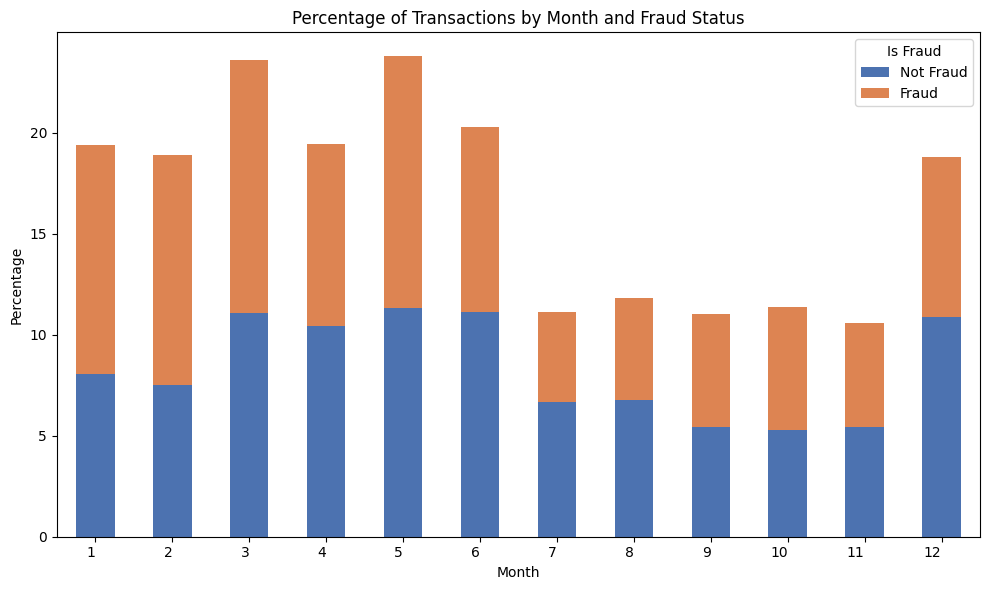

In [28]:
# Perform Chi-Square Test
contingency_table_percent = st.chi_square_test(df, 'trans_month', 'is_fraud')
contingency_table_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#4c72b0', '#dd8452']  # Optional: custom colors for clarity
)

plt.ylabel('Percentage')
plt.xlabel('Month')
plt.title('Percentage of Transactions by Month and Fraud Status')
plt.legend(['Not Fraud', 'Fraud'], title='Is Fraud')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

#### Summary
- The Chi-Square test provides strong statistical evidence to conclude that there is a significant association between the month of a transaction and whether or not it is fraudulent.
- Some months, like January, February, March, and May, appear to have a relatively higher proportion of fraudulent transactions compared to their overall transaction volume.
- Conversely, months like December, July, April, and November, show a comparatively lower proportion of fraud relative to their total transaction activity. December is particularly notable for its high volume of non-fraudulent transactions but a relatively lower percentage of fraud.
- This finding suggests that the month of the year is a relevant factor in understanding and potentially predicting fraudulent activity. Further investigation into seasonal patterns, holidays, or specific events occurring in these months could provide deeper insights into the underlying reasons for these variations.

--- Chi-Square Test between 'category' and 'is_fraud' ---
Contingency Table (Observed):
is_fraud        0 (count)  1 (count)  0 (%)  1 (%)
category                                          
entertainment       93781        233   7.27   3.10
food_dining         91310        151   7.08   2.01
gas_transport      131041        618  10.16   8.23
grocery_net         45318        134   3.52   1.79
grocery_pos        121895       1743   9.46  23.22
health_fitness      85746        133   6.65   1.77
home               122917        198   9.53   2.64
kids_pets          112796        239   8.75   3.18
misc_net            62372        915   4.84  12.19
misc_pos            79405        250   6.16   3.33
personal_care       90538        220   7.02   2.93
shopping_net        95830       1713   7.43  22.82
shopping_pos       115829        843   8.98  11.23
travel              40391        116   3.13   1.55

Expected Frequencies:
is_fraud                    0           1
category                       

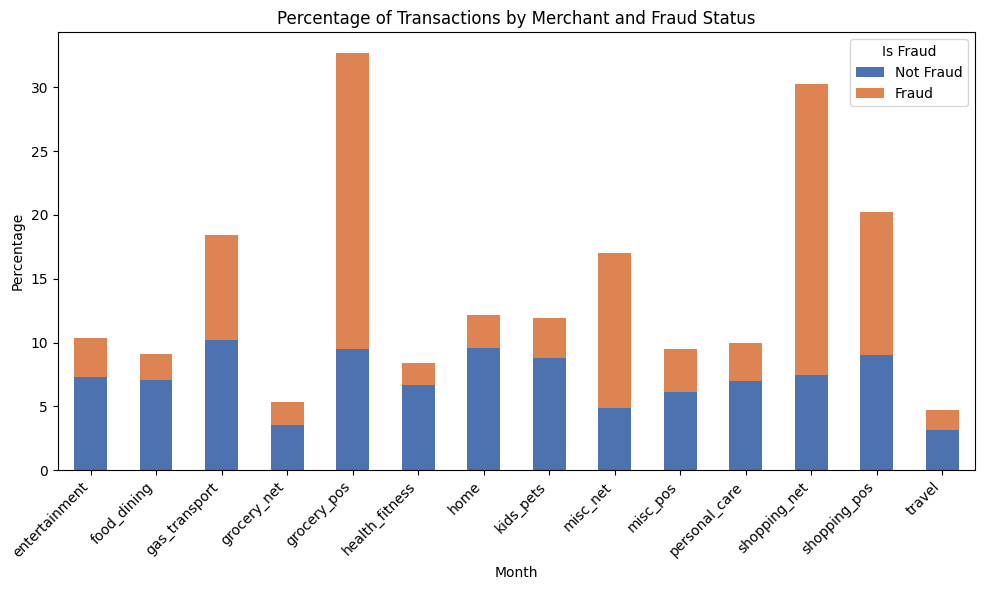

In [29]:
# Perform Chi-Square Test
contingency_table_percent = st.chi_square_test(df, 'category', 'is_fraud')
contingency_table_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#4c72b0', '#dd8452']  # Optional: custom colors for clarity
)

plt.ylabel('Percentage')
plt.xlabel('Month')
plt.title('Percentage of Transactions by Merchant and Fraud Status')
plt.legend(['Not Fraud', 'Fraud'], title='Is Fraud')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#### Summary
- This Chi-Square test definitively shows strong statistical evidence that there is a significant association between the transaction 'category' and whether or not a transaction is fraudulent.
- Fraud Risk by Category: Certain transaction categories, most notably 'grocery_pos', 'shopping_net', and 'misc_net', exhibit a significantly higher propensity for fraud compared to their overall transaction volume. These are critical areas for fraud detection and prevention efforts.
- Lower Risk Categories: Conversely, categories like 'entertainment', 'food_dining', 'health_fitness', and 'home' appear to have a relatively lower fraud risk.
- This information is highly valuable for building fraud detection models, implementing targeted fraud prevention rules, or designing specific monitoring for high-risk categories.
    - High-Risk Categories:
        - grocery_pos and shopping_net are top fraud targets, each accounting for 23% of fraud but much lower share of total transactions.
        - misc_net also stands out with 12% of fraud from just 5% of transactions.
    - Low-Risk Categories:
        - Categories like entertainment, food_dining, health_fitness, and travel show significantly less fraud than expected.

--- Chi-Square Test between 'industry' and 'is_fraud' ---
Contingency Table (Observed):
is_fraud                                                      0 (count)  1 (count)  0 (%)  1 (%)
industry                                                                                        
Airlines                                                          39639        254   3.07   3.38
Airlines & Financial                                             127519        699   9.89   9.31
Banking & Financial (e.g., Mastercard)                            61292        419   4.75   5.58
Banking & Financial (e.g., Visa)                                 416384       2441  32.30  32.52
Merchandising & Banking (e.g., Discover)                         160879       1013  12.48  13.50
Travel & Entertainment (e.g., American Express, Diners Club)     483456       2680  37.50  35.70

Expected Frequencies:
is_fraud                                                        0            1
industry                          

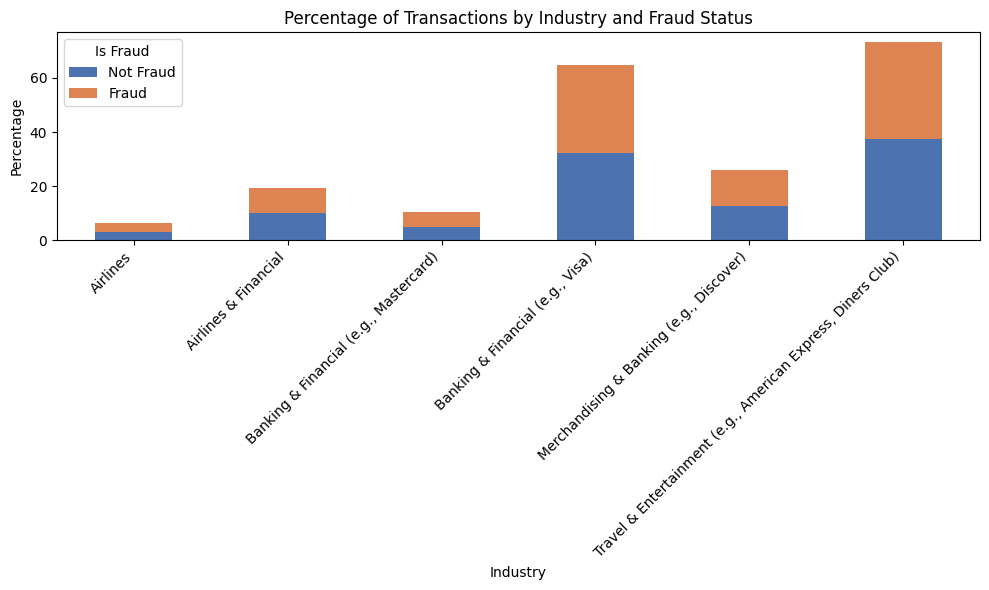

In [30]:
# Perform Chi-Square Test
contingency_table_percent = st.chi_square_test(df, 'industry', 'is_fraud')
contingency_table_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#4c72b0', '#dd8452']  # Optional: custom colors for clarity
)

plt.ylabel('Percentage')
plt.xlabel('Industry')
plt.title('Percentage of Transactions by Industry and Fraud Status')
plt.legend(['Not Fraud', 'Fraud'], title='Is Fraud')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Summary
- The Chi-Square test provides statistically significant evidence that there is an association between the 'industry' and whether a transaction is fraudulent.
- While some industries show very proportional fraud rates (like Visa and Amex/Diners Club due to their large overall volumes), others exhibit slight but statistically significant deviations. Specifically:
    - Airlines and Banking & Financial (e.g., Mastercard) show a slightly higher percentage of fraudulent transactions compared to their overall transaction volume, suggesting a marginally elevated risk.
    - Airlines & Financial shows a slightly lower percentage of fraudulent transactions.
    - Although the proportional differences might seem small at first glance, the large number of observations (counts) gives the test enough power to detect these subtle but statistically significant variations. This means the distribution of fraud is not perfectly uniform across these industry types.

--- Chi-Square Test between 'cc_network' and 'is_fraud' ---
Contingency Table (Observed):
is_fraud          0 (count)  1 (count)  0 (%)  1 (%)
cc_network                                          
American Express     123208        626   9.56   8.34
Diners Club          125382        603   9.73   8.03
Discover             104786        650   8.13   8.66
JCB                  145994        944  11.32  12.58
Maestro               96959        620   7.52   8.26
Mastercard            95943        622   7.44   8.29
Unknown              180513       1000  14.00  13.32
Visa                 416384       2441  32.30  32.52

Expected Frequencies:
is_fraud                      0            1
cc_network                                  
American Express  123117.168100   716.831900
Diners Club       125255.716710   729.283290
Discover          104825.667715   610.332285
JCB               146087.427090   850.572910
Maestro            97014.149151   564.850849
Mastercard         96006.018844   558.9811

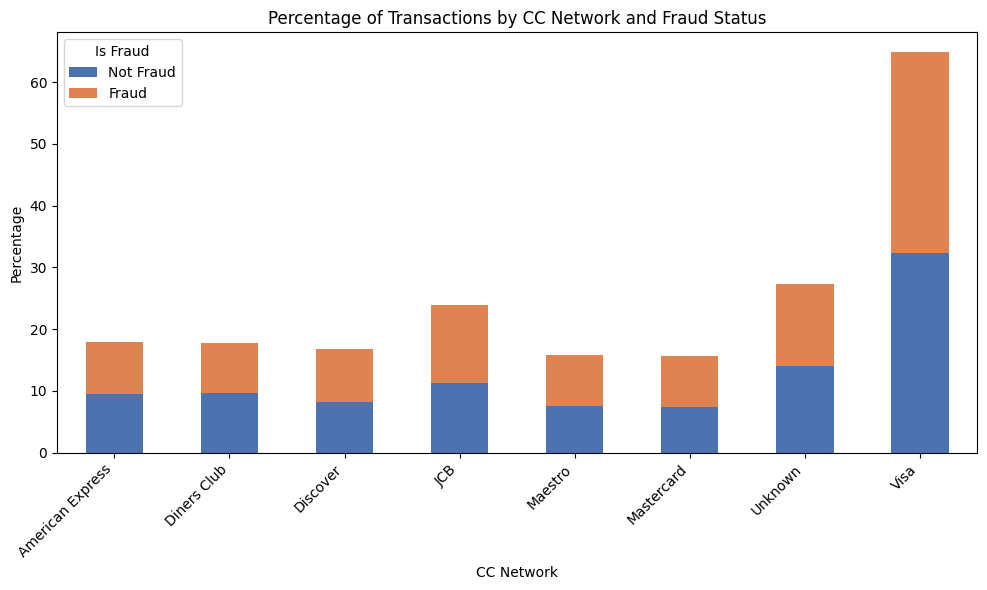

In [31]:
# Perform Chi-Square Test
contingency_table_percent = st.chi_square_test(df, 'cc_network', 'is_fraud')
contingency_table_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#4c72b0', '#dd8452']  # Optional: custom colors for clarity
)

plt.ylabel('Percentage')
plt.xlabel('CC Network')
plt.title('Percentage of Transactions by CC Network and Fraud Status')
plt.legend(['Not Fraud', 'Fraud'], title='Is Fraud')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Summary
- The Chi-Square test provides strong statistical evidence that there is a significant association between the credit card network used for a transaction and whether or not that transaction is fraudulent.
- While some networks like Visa and Discover show very proportional fraud rates (meaning their share of fraud is similar to their share of overall transactions), the statistical significance arises from the deviations seen in other networks:
- JCB and Maestro appear to be slightly overrepresented in fraudulent transactions (meaning a higher percentage of total fraud involves these networks than their percentage of total non-fraudulent transactions).
- Diners Club appears to be slightly underrepresented in fraudulent transactions.
- These differences, although sometimes appearing small in percentage points, are consistently strong enough across the large dataset to be considered statistically significant, meaning they are unlikely due to random chance. This indicates that the credit card network can be a relevant factor in fraud analysis and detection.

--- Chi-Square Test between 'gender' and 'is_fraud' ---
Contingency Table (Observed):
is_fraud  0 (count)  1 (count)  0 (%)  1 (%)
gender                                      
F            706128       3735  54.77  49.76
M            583041       3771  45.23  50.24

Expected Frequencies:
is_fraud              0            1
gender                              
F         705753.850307  4109.149693
M         583415.149693  3396.850307

Chi-square Statistic = 75.5146
Degrees of Freedom   = 1
P-value              = 0.0000
➡️ Statistically significant association (Reject Null Hypothesis)


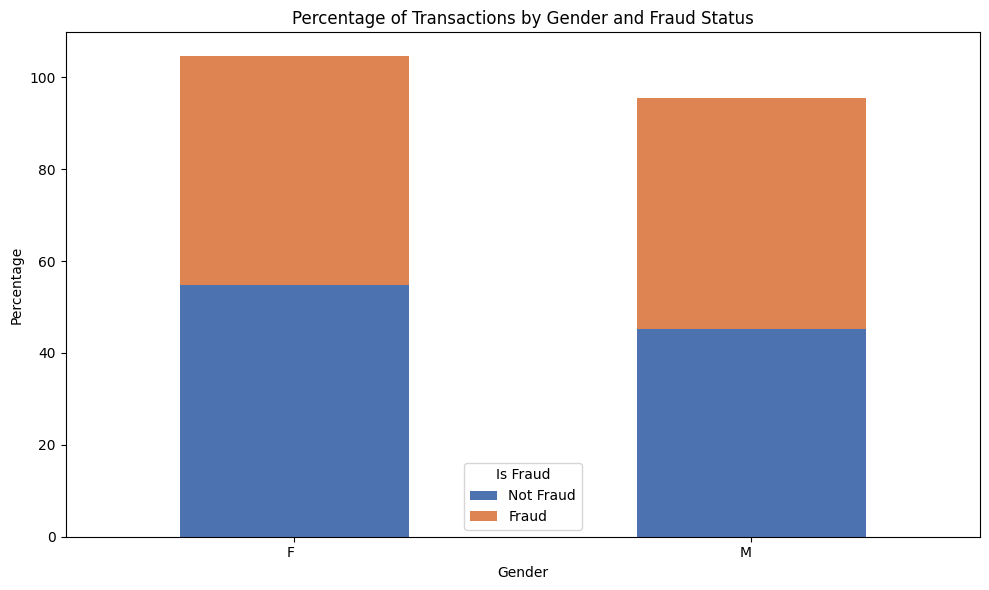

In [32]:
# Perform Chi-Square Test
contingency_table_percent = st.chi_square_test(df, 'gender', 'is_fraud')
contingency_table_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#4c72b0', '#dd8452']  # Optional: custom colors for clarity
)

plt.ylabel('Percentage')
plt.xlabel('Gender')
plt.title('Percentage of Transactions by Gender and Fraud Status')
plt.legend(['Not Fraud', 'Fraud'], title='Is Fraud')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

#### Summary
- The Chi-Square test provides strong statistical evidence that there is a significant association between 'gender' and whether or not a transaction is fraudulent.
- Although the percentage differences might seem small (e.g., 45.23% vs 54.77% for females), the extremely large sample size allows even these subtle variations to be statistically significant.
- While females account for a larger share of overall transactions, they are less likely to be involved in fraudulent transactions when compared to their overall transaction volume.
- Conversely, males account for a smaller share of overall transactions, but are more likely to be involved in fraudulent transactions when compared to their overall transaction volume.
- This doesn't mean that one gender is inherently "more fraudulent" than the other, but rather that there's a detectable pattern in how fraud manifests across gender categories within this dataset. This insight could be used to inform fraud detection models or risk assessment strategies, as gender appears to be a statistically relevant feature.

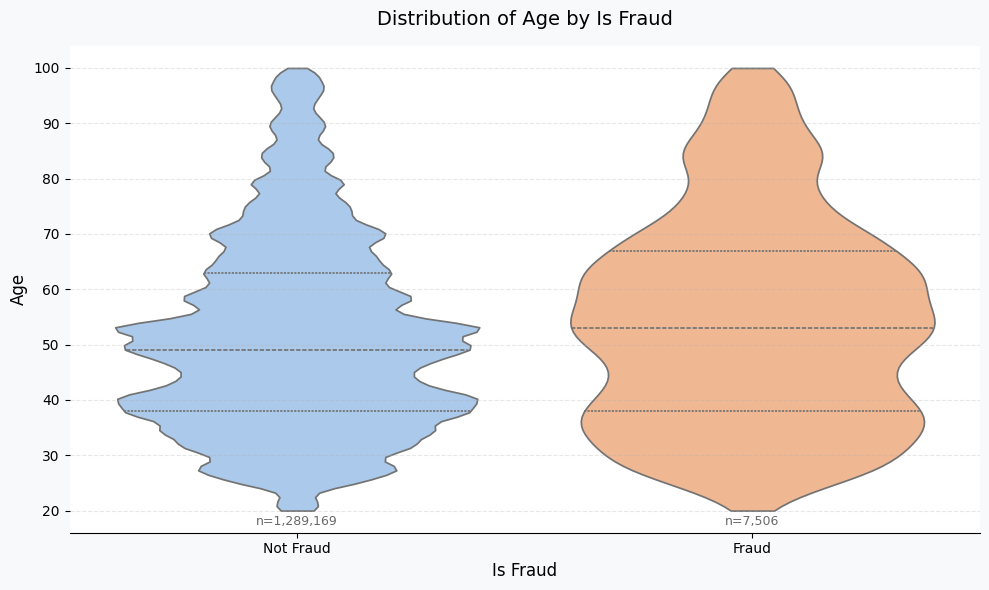

In [33]:
pf.plot_violin_by_binary_category(df, 'is_fraud', 'age')

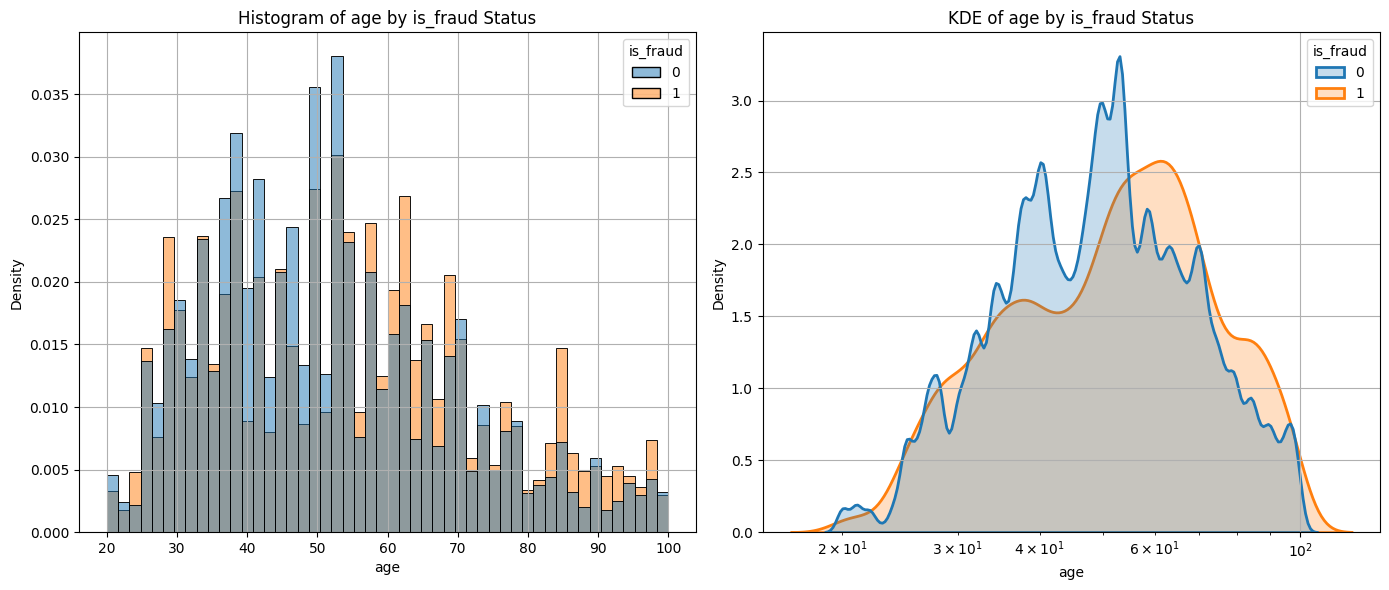

In [34]:
pf.plot_distribution(df, 'age', 'is_fraud', log_scale=False, bins=50)

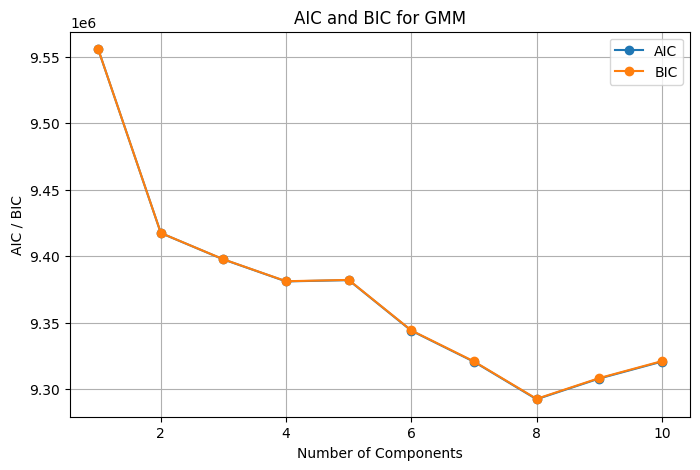

In [35]:
# Determine optimal bins using Gaussian Mixture Model
st.gaussian_mixture_binning(df, ['age'], RANDOM_STATE)

In [36]:
# Descretize age into 6 bins based on GMM results
df = st.discretization(df, 'age', 'age_group', 8, 'Age Group')

df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,trans_month_cos,trans_day_of_week_sin,trans_day_of_week_cos,age,store_distance_haversine_km,industry,cc_network,amt_log,city_pop_log,age_group
0,0,2019-01-01 00:00:18,2703186189652095,"Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,0.866025,0.781831,0.62349,37,78.597677,Airlines & Financial,Mastercard,1.786747,8.159375,Age Group(32-38)
1,1,2019-01-01 00:00:44,630423337322,"Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,0.866025,0.781831,0.62349,47,30.212217,"Merchandising & Banking (e.g., Discover)",Maestro,4.684259,5.010635,Age Group(43-49)
2,2,2019-01-01 00:00:51,38859492057661,Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,0.866025,0.781831,0.62349,63,108.206232,"Travel & Entertainment (e.g., American Express...",Diners Club,5.398660,8.332068,Age Group(54-63)
3,3,2019-01-01 00:01:16,3534093764340240,"Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,0.866025,0.781831,0.62349,58,95.673363,"Travel & Entertainment (e.g., American Express...",JCB,3.828641,7.570443,Age Group(54-63)
4,4,2019-01-01 00:03:06,375534208663984,Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,0.866025,0.781831,0.62349,39,77.556851,"Travel & Entertainment (e.g., American Express...",American Express,3.760269,4.605170,Age Group(38-43)


--- Chi-Square Test between 'age_group' and 'is_fraud' ---
Contingency Table (Observed):
is_fraud           0 (count)  1 (count)  0 (%)  1 (%)
age_group                                            
Age Group(20-32)      168705       1031  13.09  13.74
Age Group(32-38)      167274        881  12.98  11.74
Age Group(38-43)      152800        568  11.85   7.57
Age Group(43-49)      156400        716  12.13   9.54
Age Group(49-54)      166714        741  12.93   9.87
Age Group(54-63)      175809       1290  13.64  17.19
Age Group(63-73)      145559       1052  11.29  14.02
Age Group(73-100)     155908       1227  12.09  16.35

Expected Frequencies:
is_fraud                       0            1
age_group                                    
Age Group(20-32)   168753.457408   982.542592
Age Group(32-38)   167181.609266   973.390734
Age Group(38-43)   152480.206059   887.793941
Age Group(43-49)   156206.510193   909.489807
Age Group(49-54)   166485.661322   969.338678
Age Group(54-63)   176073.

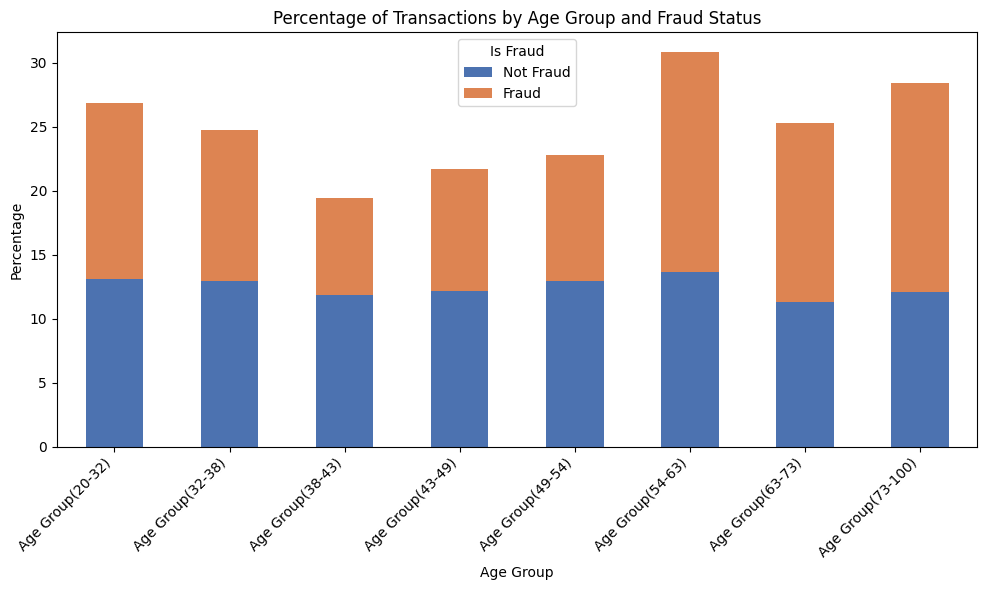

In [37]:
# Perform Chi-Square Test
contingency_table_percent = st.chi_square_test(df, 'age_group', 'is_fraud')
contingency_table_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#4c72b0', '#dd8452']  # Optional: custom colors for clarity
)

plt.ylabel('Percentage')
plt.xlabel('Age Group')
plt.title('Percentage of Transactions by Age Group and Fraud Status')
plt.legend(['Not Fraud', 'Fraud'], title='Is Fraud')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Summary
The test results are overwhelming: P-value =0.0000 and a high Chi-square Statistic (451.8011). We definitively reject the Null Hypothesis of independence.

1. Group-by-Group Risk Assessment
The most effective way to analyze this is to compare the proportion of transactions each group contributes to the non-fraud pool (0 (%)) versus the fraud pool (1 (%)).

| Age Group | % Non-Fraud (0) | % Fraud (1) | Interpretation (Relative Risk) |
|:---:|:---:|:---:|:---:|
| Age Group (20-32) | 13.09% | 13.74% | Slightly Elevated Risk (Fraud contribution is higher than non-fraud contribution). |
| Age Group (32-38)	| 12.98% | 11.74% | Neutral/Expected Risk (Fraud contribution is slightly lower than non-fraud contribution). |
| Age Group (38-43)	| 11.85% |	7.57% |	LOWEST RISK (Strongly under-represented in fraud). |
| Age Group (43-49)	| 12.13% |	9.54% |	Low Risk (Under-represented in fraud). |
| Age Group (49-54)	| 12.93% |	9.87% |	Low Risk (Under-represented in fraud). |
| Age Group (54-63)	| 13.64% | 17.19% |	<span style="color: red;">HIGH RISK</span> (Significantly over-represented in fraud). |
| Age Group (63-73)	| 11.29% | 14.02% |	<span style="color: red;">HIGH RISK</span>  (Significantly over-represented in fraud). |
| Age Group (73-100)| 12.09% | 16.35% |	<span style="color: red;">HIGHEST RISK</span> (Most disproportionately affected by fraud). |

2. Strategic Insights
This fine-grained analysis allows for specific, targeted policy recommendations:
    - The Safest Zone (Ages 38-54): The three middle age groups (38−43, 43−49, and 49−54) consistently show a lower percentage of fraud relative to their total transaction volume. The 38−43 group is the safest, contributing only 7.57% to the fraud pool. This suggests these groups are most resilient to or least targeted by common fraud schemes.
    - The Highest Risk Zone (Ages 54+): The data shows a clear inflection point around age 54. The groups 54-63, 63-73, and 73-100 all have fraud percentages that are significantly higher than their general transaction percentages. The risk escalates dramatically with age:
        - Age 54-63: 17.19% fraud vs. 13.64% non-fraud.
        - Age 73-100: 16.35% fraud vs. 12.09% non-fraud.

Targeted Intervention: Any fraud prevention or security awareness campaign should be heavily tailored for the 54+ demographic  to address their elevated vulnerability, while the middle age groups might require less aggressive default monitoring.

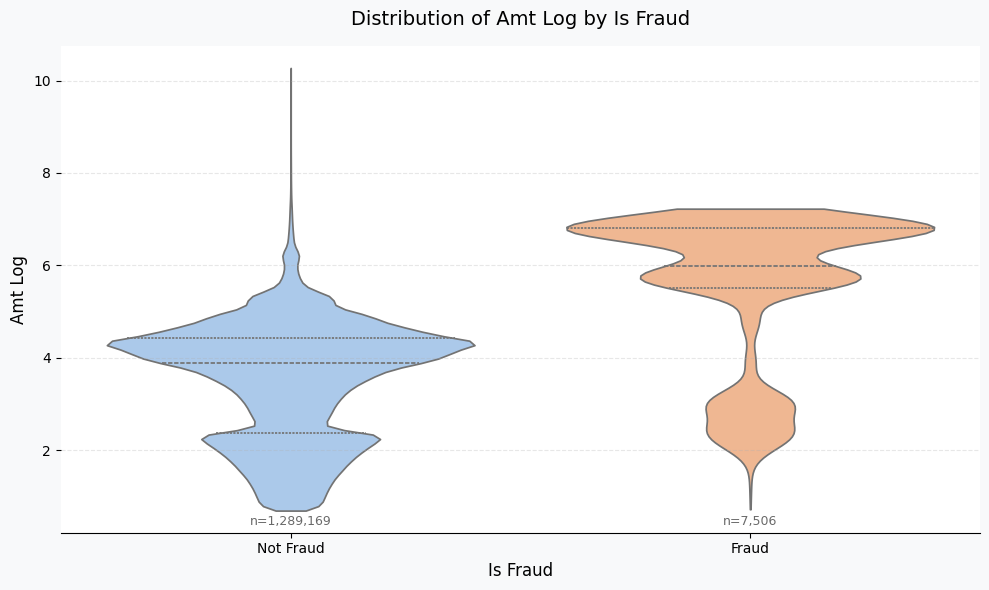

In [38]:
pf.plot_violin_by_binary_category(df, 'is_fraud', 'amt_log')

Plot saved to ../Image/Amount_Distribution_Log.png with 600 DPI.


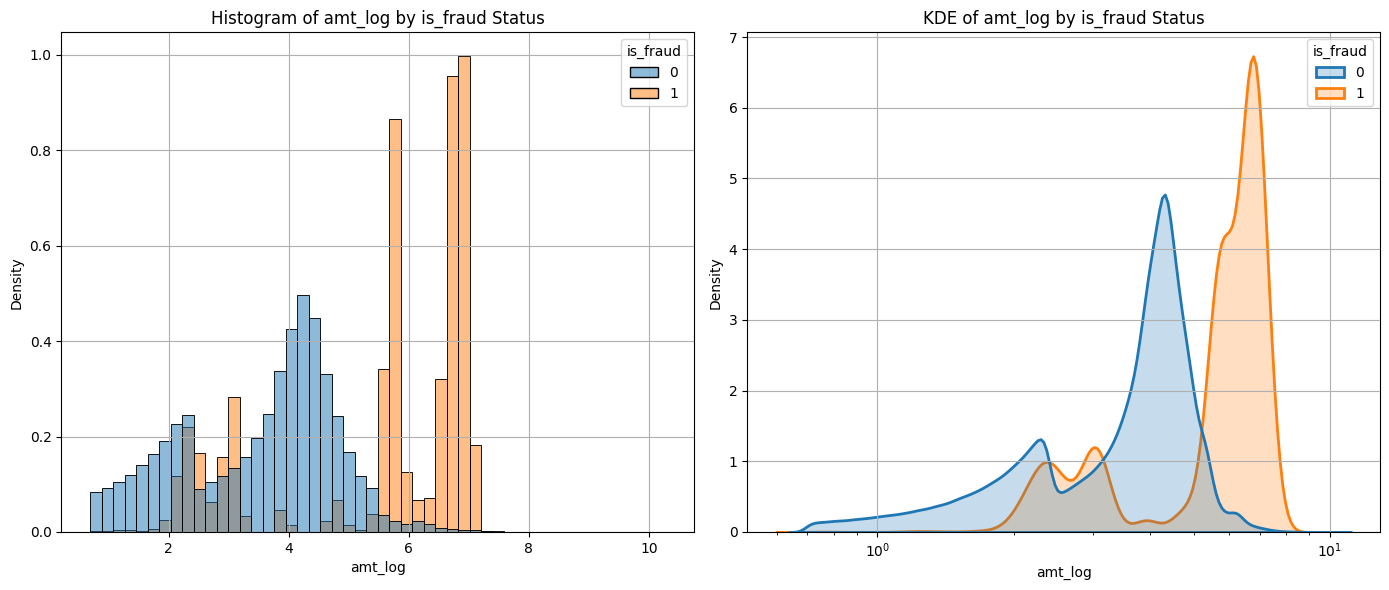

In [39]:
pf.plot_distribution(df, 'amt_log', 'is_fraud', save_path="../Image/Amount_Distribution_Log.png", dpi=600, log_scale=False, bins=50)

#### Summary
- Transaction Amount and Fraud Analysis
    - Fraudulent transactions occur across a broad spectrum of transaction amounts, indicating that fraud is not limited to high-dollar or low-dollar amounts exclusively. However, there is a clear trend of increasing fraud density as transaction amounts rise.
- Implications:
    - It may be worthwhile to establish tiered fraud monitoring thresholds, allocating more scrutiny to high-value transactions during peak fraud hours (e.g., 22:00–03:00).
    - Further analysis could examine interaction effects between transaction amount and other features such as merchant type, category type, or card network to uncover multi-dimensional fraud patterns.

Plot saved to ../Image/Pop_Distribution_log.png with 600 DPI.


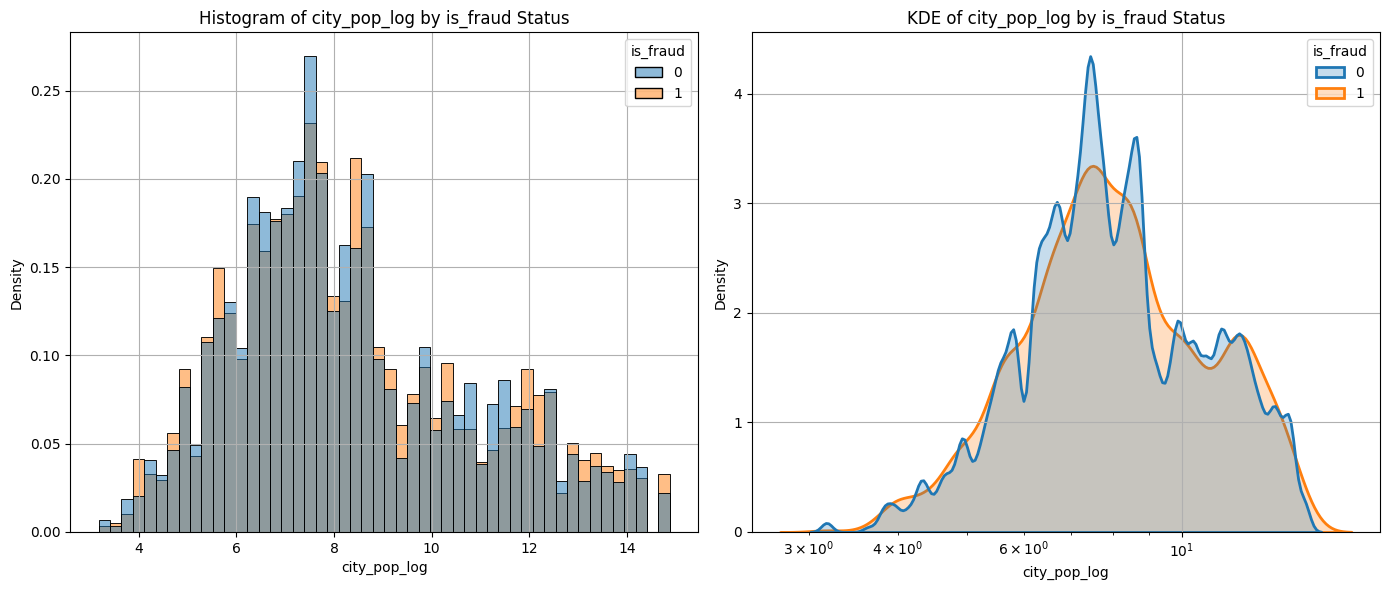

In [40]:
pf.plot_distribution(df, 'city_pop_log', 'is_fraud', save_path="../Image/Pop_Distribution_log.png", dpi=600, log_scale=False, bins=50)

Plot saved to ../Image/Distance_Distribution_Log.png with 600 DPI.


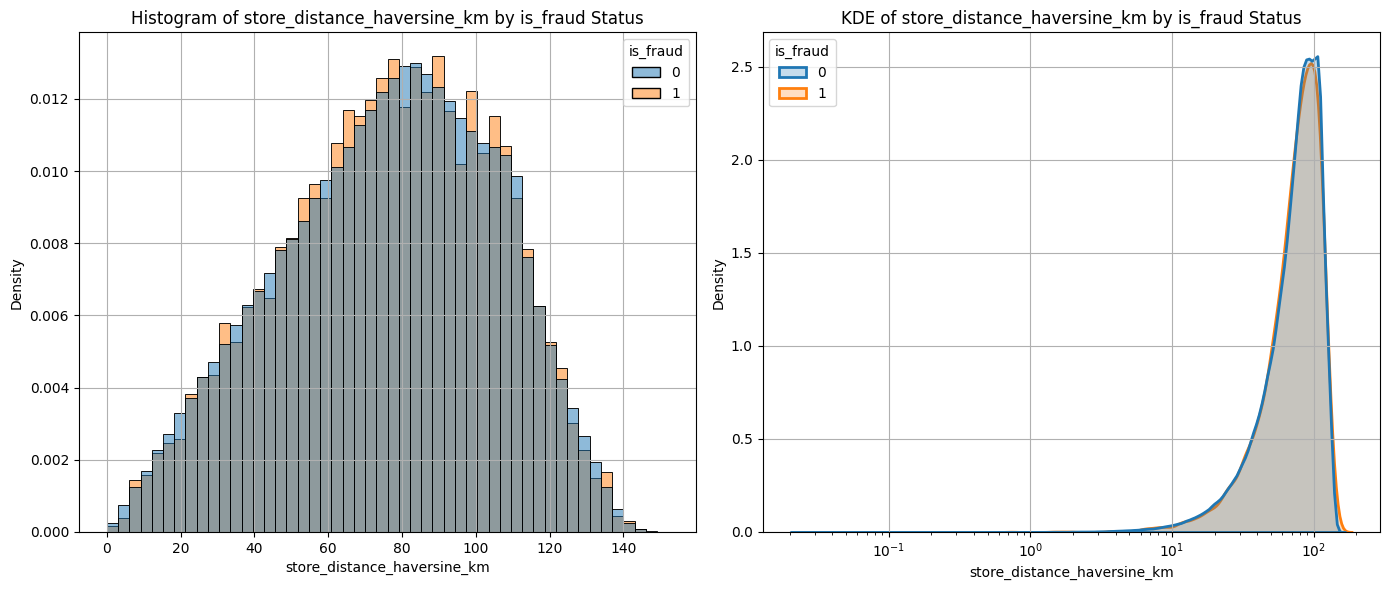

In [41]:
pf.plot_distribution(df, 'store_distance_haversine_km', 'is_fraud', save_path="../Image/Distance_Distribution_Log.png", dpi=600, log_scale=False, bins=50)

In [42]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Filter for fraudulent transactions
fraud_df = df[df['is_fraud'] == 1].copy() # Use .copy() to avoid SettingWithCopyWarning

# One-Way ANOVA using OLS (similar to scipy.stats.f_oneway but more detailed output)
# The formula 'C(merchant)' tells statsmodels that 'merchant' is a categorical variable
model = ols('amt ~ C(category)', data=fraud_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2) # typ=2 or typ=3 for different types of sum of squares

print("ANOVA Table for Fraudulent Transaction Amounts by Merchant Category (using statsmodels):")
print(anova_table)

# Two-Way ANOVA (to examine category and cc_network simultaneously)
# And to test for interaction effects: category:cc_network
model_two_way = ols('amt ~ C(category) + C(cc_network) + C(category):C(cc_network)', data=fraud_df).fit()
anova_table_two_way = sm.stats.anova_lm(model_two_way, typ=2) # Type II sums of squares are generally appropriate for unbalanced designs

print("\nANOVA Table for Fraudulent Transaction Amounts by Category, Card Network, and their Interaction:")
print(anova_table_two_way)

ANOVA Table for Fraudulent Transaction Amounts by Merchant Category (using statsmodels):
                   sum_sq      df            F  PR(>F)
C(category)  1.077345e+09    13.0  9205.587569     0.0
Residual     6.744625e+07  7492.0          NaN     NaN

ANOVA Table for Fraudulent Transaction Amounts by Category, Card Network, and their Interaction:
                                 sum_sq      df            F        PR(>F)
C(category)                1.076264e+09    13.0  9462.367699  0.000000e+00
C(cc_network)              1.047638e+05     7.0     1.710558  1.016074e-01
C(category):C(cc_network)  2.648825e+06    91.0     3.326874  6.673751e-24
Residual                   6.469266e+07  7394.0          NaN           NaN


### Summary
**One-Way ANOVA (by Merchant Category)**
- There is a statistically significant difference in the mean fraudulent transaction amounts across merchant categories, and the average fraud amount is not the same for all merchant types.

**Two-Way ANOVA (Category, Card Network, and Interaction)**
- Merchant category remains highly significant (p-value ≈ 0), confirming it strongly affects fraudulent transaction amounts.
- Card network alone is not significant (p-value ≈ 0.10), so it does not independently affect the fraud amount.
- Interaction (Category × Card Network) is highly significant (p-value ≈ 0), indicating that the effect of merchant category on fraud amount depends on the card network used. There are specific combinations of merchant categories and card networks that lead to significantly different average fraudulent transaction amounts. This suggests a more complex pattern where the risk associated with a merchant category depends on the card network being used.

<Figure size 1800x900 with 0 Axes>

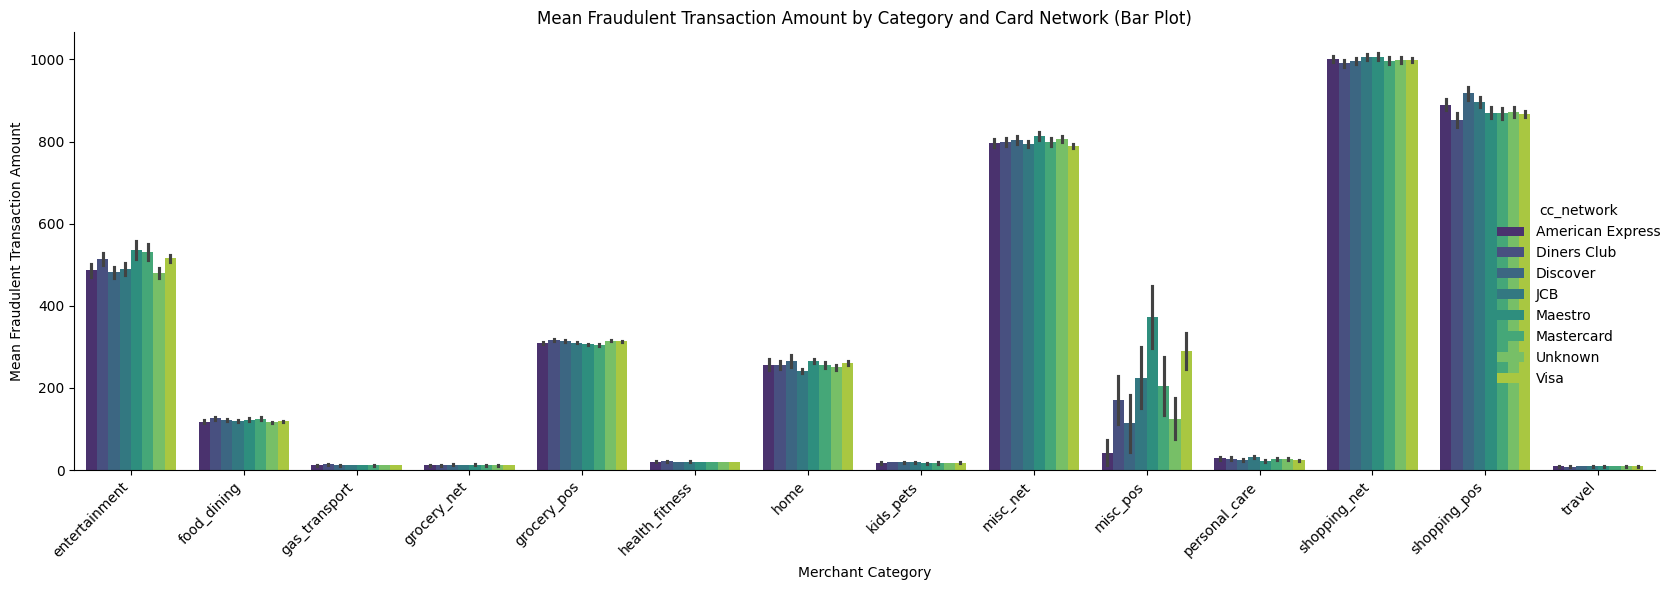

In [43]:
# Set DPI and save path
dpi = 1200
save_path = "../Image/Mean_Fraud_Amount_by_Category_and_CC_Network.png"

# Plotting the interaction
plt.figure(figsize=(18, 9))
sns.catplot(data=fraud_df, x='category', y='amt', hue='cc_network', kind='bar',
            errorbar='se', palette='viridis', height=6, aspect=2.5)
plt.title('Mean Fraudulent Transaction Amount by Category and Card Network (Bar Plot)')
plt.xlabel('Merchant Category')
plt.ylabel('Mean Fraudulent Transaction Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(save_path, dpi=dpi) # Added dpi argument here
plt.show()

#### Highest Mean Fraud Amounts (Overall):
- `shopping_net` (Online Shopping) consistently shows the highest mean fraudulent transaction amounts, often around $1000 across most card networks. This indicates that when fraud occurs in online shopping, it tends to involve large sums.
- `misc_net` (Miscellaneous Online) is also very high, with mean fraudulent amounts consistently around $800.

#### Lowest Mean Fraud Amounts:
- `gas_transport` and `grocery_net` (Online Grocery) consistently have very low mean fraudulent amounts, generally ranging from $11 to $13. This suggests that while fraud might occur in these categories, it typically involves smaller sums.
- `travel` also shows very low mean fraudulent amounts (around $8 - $10), which might be counter-intuitive as travel transactions can be expensive. This could indicate that while there might be many fraudulent travel transactions, their individual values are low, perhaps due to specific types of small-ticket travel fraud.

#### Variability within Categories (Interaction Effect in action):
- For categories like `misc_pos` (Miscellaneous Point-of-Sale), you can see significant variation across card networks. For instance, `American Express` has a mean of nearly $40, while `Maestro` is about $400, and `JCB` is bit over $200. This is a clear example of the interaction effect; the mean fraudulent amount for `misc_pos` depends heavily on the `cc_network` used, and this combination could be "high-risk pairing".
- `entertainment`, `food_dining`, `home`, `health_fitness`, `kids_pets`, `personal_care`, `shopping_pos` show relatively less variation across networks within their respective categories, though minor differences exist. For example, in `entertainment`, values range from approximately $480 to $540, a tighter range than `misc_pos`.


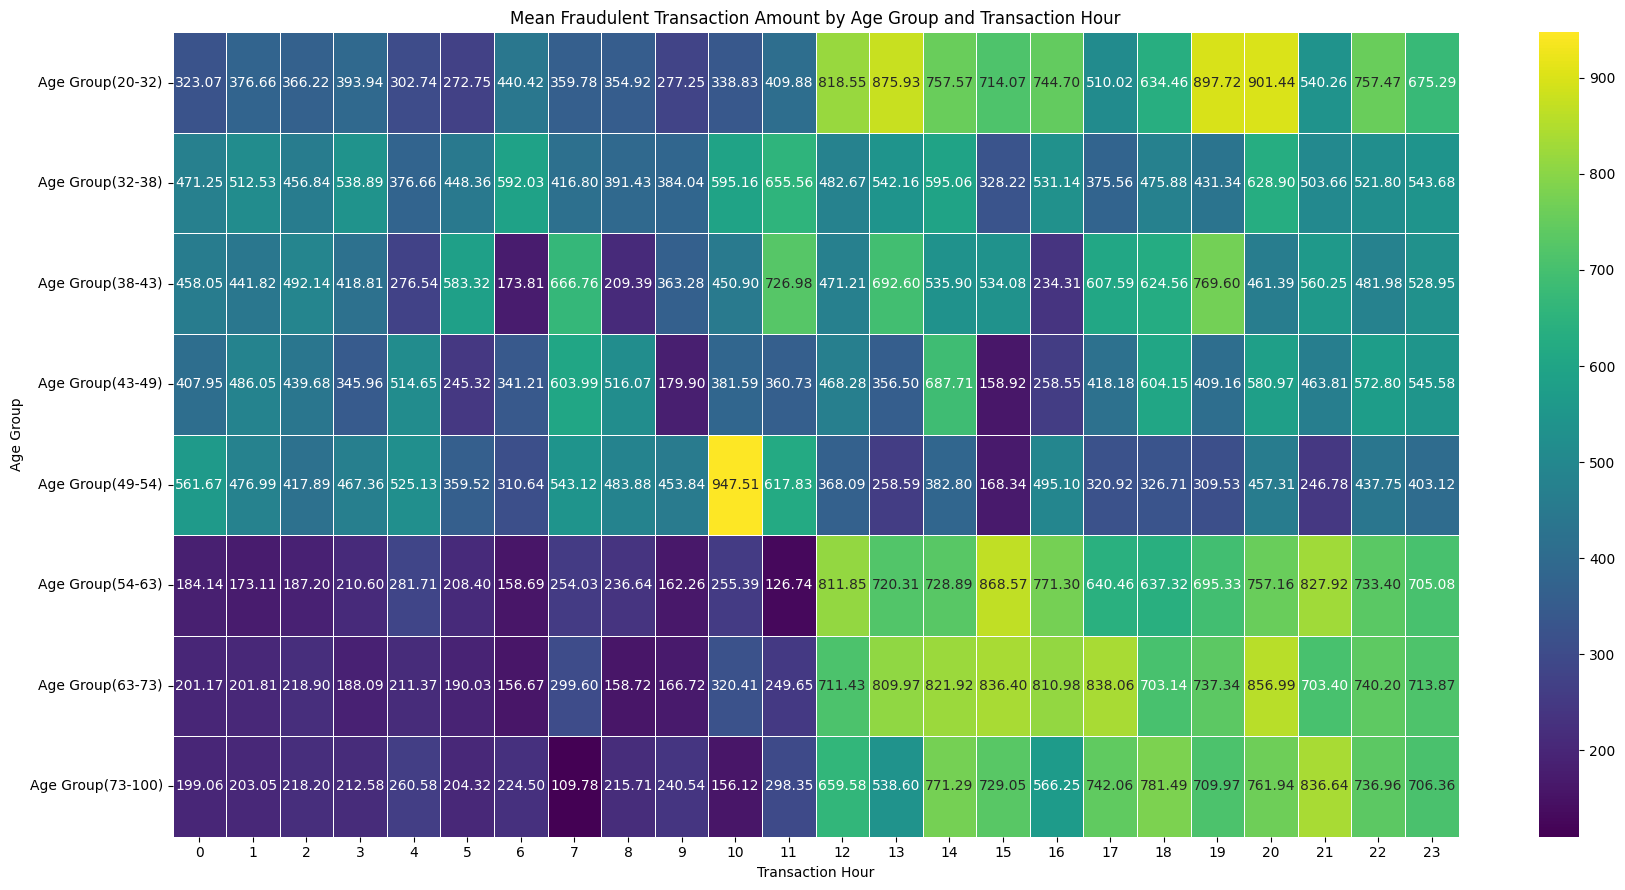

In [44]:
# Set DPI and save path
dpi = 1200
save_path = "../Image/Mean_Fraud_Amount_by_Age_Group_and_Transaction_Hour.png"

# Create a pivot table to get the mean fraudulent amount for each combination
mean_fraud_amount = fraud_df.groupby(['age_group', 'trans_hour'], observed=False)['amt'].mean().unstack()

# Plotting the interaction
plt.figure(figsize=(18, 9))
sns.heatmap(mean_fraud_amount, cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
plt.title('Mean Fraudulent Transaction Amount by Age Group and Transaction Hour')
plt.xlabel('Transaction Hour')
plt.ylabel('Age Group')
plt.tight_layout()
plt.savefig(save_path, dpi=dpi)
plt.show()

##### Summary
1. High-Value Fraud Hours (All Ages)
    - Across nearly all age groups, the mean fraudulent transaction amount tends to be highest during specific windows, indicated by the brightest yellow/green colors:
    - Midday/Lunch Hour (12:00 - 15:00): Fraud amounts spike significantly, peaking generally between 12 PM and 3 PM.
    - Evening (18:00 - 23:00): Amounts rise again in the late afternoon and evening, suggesting fraudsters may be taking advantage of times when people are distracted or winding down.

2. Low-Value Fraud Hours (All Ages)
- Fraud amounts are consistently lower during:
    - Early Morning (0:00 - 4:00): This is the window where the dark purple/blue colors dominate, suggesting fewer high-value attacks happen during standard sleeping hours.

3. Age Group-Specific Risk Patterns

| Age Group |Peak Fraud Amount | Peak Time Window | Key Observation |
|:---|:---:|:---:|:---:|
| Youngest (20-32)| ∼$975 | 18:00 - 23:00 | This group exhibits the single highest mean fraudulent transaction amount, suggesting they are victims of the most expensive individual frauds, primarily in the evening. |
| Middle (38-43)| ∼$775| 12:00 - 15:00 | High-value fraud is concentrated during the midday/lunch break, suggesting scams or card usage when they might be busy.|
| Oldest (63-100)| ∼$966| 13:00 - 22:00 | These groups experience consistently high mean fraud amounts throughout the day, particularly peaking in the late afternoon and evening, supporting the finding that this demographic is highly susceptible to high-value scams.|
|Ages 54-63| ∼$780|	13:00 - 16:00 |	This group's risk profile is visually distinct, showing a high concentration of moderate-to-high amounts during a slightly earlier midday window. |


##### Summary of Risk Zones
- Highest Value Risk: The combination of Age Group (20-32) and the Evening Hours (18:00-23:00) shows the largest mean fraud amounts, indicating this is when the most costly single incidents occur.
- Broadest High-Value Risk: The 63+ age groups are at high risk for large fraudulent transactions spanning most of the day, particularly from 13:00 to 22:00.
- This analysis suggests that monitoring models should assign higher risk weights to transactions occurring during the peak midday and evening hours, especially when involving the 20−32 and 63+ age brackets.